# A year in one market

This is the shortest useful thing tradefloor does: run a market for a
trading year, watch one company, and see what happened to it and why.

Everything here is deterministic. The same seed gives the same year on
any machine -- Linux, macOS and Windows agree bit for bit, and a CI
gate compares digests across five targets to prove it. It does NOT
give the same year forever: coefficients are frozen under a preset
name, and when a new preset becomes the default every seeded
trajectory moves. That is an era boundary, announced in the changelog,
and it is why the cell below prints the preset alongside the
fingerprint. Nothing is downloaded and nothing is random in the sense
of being unrepeatable.

You need `pip install 'tradefloor[arrow]' matplotlib`. The core library
has no dependencies of its own; the `arrow` extra is the pyarrow the
cells below use to read the engine's tables. It runs in a few seconds.

## The market

A universe is a roster of companies. Here one is built by hand with
Apple's rough shape (price, share count, earnings, book value) and
thirty-nine others are generated, so the market has something to
co-move with. The numbers are a starting state, not a forecast: this
is a company like Apple in a market like the US one, not Apple.

In [1]:
import tradefloor as tf

aapl = tf.Instrument(
    "AAPL", "technology",
    initial_price=75.0,          # roughly where it started 2020
    shares_outstanding=17.77e9,
    eps=2.97,
    book_value_per_share=5.09,
    avg_volume=140e6,
    beta=1.2,
)

universe = tf.Universe([aapl])
universe.extend(tf.Universe.random(39, seed=7))

print(f"{len(universe)} companies, fingerprint {universe.fingerprint}")
print(f"model preset: {tf.ModelParams.from_preset().fingerprint}")

40 companies, fingerprint 1026d526bc3cadba045089233466be2b2a788434c5f370fd857d0f7baf31d00b
model preset: pt-v20


The fingerprints matter more than they look, but three of them are not
a run. `docs/reproducing-a-run.md` names FIVE things that identify one:
the version and preset, the seed, the universe, the macro initial
conditions, and the order log. This page is its own proof. The two
runs below share the preset, the universe and seed 2024 and differ
only in the macro path, and one of them falls 28.4% from its high
during the year where the other falls 15.7%.

Note also what a universe fingerprint does and does not do. It
**verifies** a universe; it does not reconstruct one. Nobody can rebuild
the hand-built AAPL plus `Universe.random(39, seed=7)` roster from the
64 hex digits above -- they can only check that the roster they were
handed is the one you ran. Ship the roster, or the code that builds it,
alongside the fingerprint.

## Two runs of the same year

Both runs use the same seed, the same companies and the same calm
baseline: the VIX pinned at 15 and corporate borrowing at 5.5%. The
second run adds two crises and nothing else, so every difference
between the two lines below is caused by them.

The two are deliberately different KINDS of crisis.

Day 60 is fear only: the VIX jumps to 45 and decays back over the next
twenty-one trading days. A VIX pin is a VOLATILITY input, not a
direction. It widens the range of what can happen without moving the
middle of it much: a bad fall and a sharp rally both get more likely,
and which one you get is still mostly the seed. Watch the first shaded
band below and you will see exactly that -- the line turns jagged and
then leaves the band about where it entered it, within a few cents of
the quiet run. A rougher ride, not a crash.

Day 150 adds a repricing to the fear: the VIX to 65 and corporate
borrowing up four points, both easing back over thirty days. The higher
discount rate marks AAPL's fair value down about 7% on day 150. On
pt-v19 it was back by day 180 as the yield eased. pt-v20 also moves each
name's own shocks into its fair value, and the frightened run's shocks are
larger, so on day 180 the two runs' fair values still differ by about 2%.

Earlier versions of this notebook also stepped `qe_pe_boost` to -30% on
day 150, a permanent valuation mark-down. That lever goes through the QE
valuation channel, whose gain `qe_pe_gain` is 0.0 on every default since
pt-v16, so on pt-v20 it moves nothing and it is left out. Under pt-v14,
where the gain is 1.0, the same step cuts AAPL's fair value by 30% and
holds it there.

So on pt-v20 the crises change the ride rather than where the year
ends. The table further down has the same company, on the same seed,
down 5.4% without the crises and 5.7% with them, while its worst fall
from a high is 28.4% against 15.7% and its volatility 30.4% against
15.6%. On pt-v19 the same two runs ended up 28.3% and 29.0%.

A scenario pins macro state. It does not tell prices what to do: the
crisis is an input, the market's reaction to it is not.

In [2]:
CALM = {"vix": 15.0, "corporate_bond_yield": 0.055}
CRISES = [
    # name, day, length, VIX peak, borrowing cost
    ("fear only", 60, 21, 45.0, None),
    ("fear + repricing", 150, 30, 65.0, 0.095),
]

quiet_scenario = tf.Scenario().hold(**CALM)

crisis_scenario = tf.Scenario().hold(**CALM)
for _name, begin, over, vix_peak, yield_peak in CRISES:
    crisis_scenario = crisis_scenario.ramp(
        "vix", start=vix_peak, end=CALM["vix"], over=over, begin=begin)
    if yield_peak is not None:
        crisis_scenario = crisis_scenario.ramp(
            "corporate_bond_yield", start=yield_peak,
            end=CALM["corporate_bond_yield"], over=over, begin=begin)

print(f"day 59: {crisis_scenario.at(59)}")
print(f"day 60: {crisis_scenario.at(60)}")
print(f"day 150: {crisis_scenario.at(150)}")

day 59: {'vix': 15.0, 'corporate_bond_yield': 0.055}
day 60: {'vix': 45.0, 'corporate_bond_yield': 0.055}
day 150: {'vix': 65.0, 'corporate_bond_yield': 0.095}


In [3]:
import pyarrow as pa, pyarrow.compute as pc

def run_year(scenario, days=252):
    engine = tf.Engine(seed=2024, universe=universe)
    for day in range(days):
        scenario.apply(engine, day)
        engine.run_days(1, first_day=day, record=True)
    return engine

def daily_close(engine, ticker="AAPL"):
    """One name's closing price per day."""
    bars = pa.table(engine.bars(grain="day"))
    idx = engine.tickers.index(ticker)
    rows = pc.filter(bars, pc.equal(bars["instrument_id"], idx))
    return rows["close"].to_pylist()

QUIET = run_year(quiet_scenario)
SHOCKED = run_year(crisis_scenario)
quiet_path = daily_close(QUIET)
shocked_path = daily_close(SHOCKED)

print(f"quiet:   {quiet_path[0]:.2f} -> {quiet_path[-1]:.2f}")
print(f"crises:  {shocked_path[0]:.2f} -> {shocked_path[-1]:.2f}")

quiet:   74.50 -> 70.50
crises:  74.50 -> 70.27


## The picture

The shaded bands are the crises. The two lines are the same company,
the same seed and the same starting state; the only difference is that
one market was frightened twice.

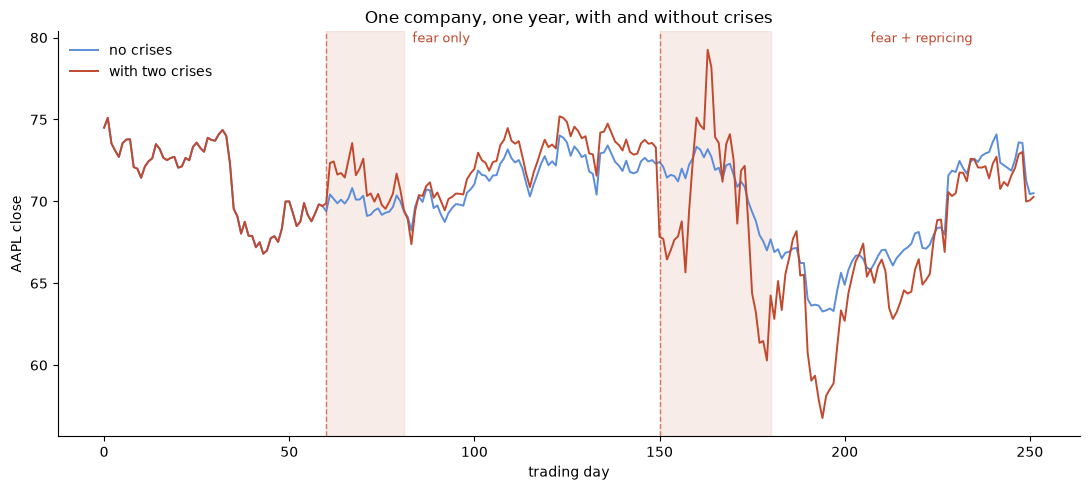

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(quiet_path, linewidth=1.4, label="no crises", color="#5b8dd9")
ax.plot(shocked_path, linewidth=1.4, label="with two crises", color="#c2492e")

for name, start, length, _vix, _yield in CRISES:
    ax.axvspan(start, start + length, color="#c2492e", alpha=0.10)
    ax.axvline(start, color="#c2492e", linewidth=1.0, linestyle="--", alpha=0.7)
    ax.annotate(name, xy=(start, ax.get_ylim()[1]), xytext=(start + 2, 0),
                textcoords="offset points", fontsize=9, color="#c2492e",
                va="top")

ax.set_xlabel("trading day")
ax.set_ylabel("AAPL close")
ax.set_title("One company, one year, with and without crises")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## What the crises did

Two numbers are worth reading off. The drawdown is how far the price
fell from its own high, which is the loss a holder actually lives
through. Realised volatility is how violent the ride was.

In [5]:
import statistics as st

def drawdown(path):
    peak, worst = path[0], 0.0
    for price in path:
        peak = max(peak, price)
        worst = min(worst, price / peak - 1)
    return worst

def annual_vol(path):
    rets = [path[i] / path[i - 1] - 1 for i in range(1, len(path))]
    return st.pstdev(rets) * 252 ** 0.5

print(f"{'':16s} {'quiet':>10s} {'with crises':>12s}")
print(f"{'return':16s} {quiet_path[-1] / quiet_path[0] - 1:>10.1%} "
      f"{shocked_path[-1] / shocked_path[0] - 1:>12.1%}")
print(f"{'max drawdown':16s} {drawdown(quiet_path):>10.1%} "
      f"{drawdown(shocked_path):>12.1%}")
print(f"{'volatility':16s} {annual_vol(quiet_path):>10.1%} "
      f"{annual_vol(shocked_path):>12.1%}")

                      quiet  with crises
return                -5.4%        -5.7%
max drawdown         -15.7%       -28.4%
volatility            15.6%        30.4%


## Why the price moved

A real market never tells you why. This one does, because it computed
the reasons: every price move is a sum of named components, and they
add up to the change exactly.

Below is AAPL through the second crisis, days 150 to 180, with each
component's total contribution. The units are the model's internal
mispricing scale rather than currency; the ranking and the signs are
what to read.

In [6]:
truth = pa.table(SHOCKED.truth())
idx = SHOCKED.tickers.index("AAPL")
window = pc.and_(
    pc.equal(truth["instrument_id"], idx),
    pc.and_(pc.greater_equal(truth["day"], 150),
            pc.less(truth["day"], 180)),
)
rows = pc.filter(truth, window)

# From the SECOND row on: the first row's components caused the move
# into the window's opening price, not a move inside it.
inside = rows.slice(1)
totals = {name: pc.sum(inside[name]).as_py() for name in tf.Engine.FACTORS}
for name, value in sorted(totals.items(), key=lambda kv: -abs(kv[1])):
    print(f"  {name:22s} {value:>+12.5f}")
print(f"  {'sum':22s} {sum(totals.values()):>+12.5f}")

s_series = rows["mispricing_s"].to_pylist()
print(f"  {'change in mispricing':22s} {s_series[-1] - s_series[0]:>+12.5f}")

  random_noise               -0.17543
  fair_value_shift           +0.07387
  jump                       -0.01768
  company_news               +0.01462
  reversion                  -0.00849
  crowd_lean                 -0.00632
  short_squeeze_effect       -0.00305
  momentum                   -0.00177
  order_flow_impact          +0.00000
  circuit_breaker            +0.00000
  overnight                  +0.00000
  sum                        -0.12426
  change in mispricing       -0.12426


The last two numbers match to the last digit. pt-v20 moves each name's
own shocks into its fair value, so part of every shock leaves the
mispricing, and `fair_value_shift`, new in 0.8.5, books that part with a
minus sign: +0.074 here, against -0.198 from the other columns. On pt-v19,
which kept every shock in the mispricing, that column is zero.

Most of this fall is `random_noise`, with `jump` a long way behind.
`reversion` is the market's own pressure back toward fair value; AAPL
opened the window above fair value and closed it below, and the pull
nets to a small negative. `company_news` is the only column that pushed
against the fall in any size.

One of the eleven only appears when the market gets rough.
`circuit_breaker` is what the session halt took off a price that tried
to leave its band. Pinning the VIX for 60 days over
`Universe.random(25, seed=7)` at seed 2024 on pt-v20, it is zero on
every name and day at VIX 10, 15 and 45 and fires on one at VIX 65
(three on pt-v19). AAPL did not reach its band in this window, so it
reads zero above.

`jump` is the daily jump, applied after the tick loop, and on pt-v20 it
grows with fear: `jump_vix_coupling` is 0.2626. The same sweep counts
7 instrument-days with a jump larger than 1% at VIX 10 against 27 at
VIX 65, and 5 against 22 larger than 2% (pt-v19: 7 against 45, and 5
against 19). The column is non-zero on almost every cell, because it also carries a small daily compensator
that keeps the jumps from adding a drift, so count jumps by size rather
than by non-zero cells. Under `pt-v12` the coupling is 0.0, and a calm
market and a panic jumped about equally often and as hard: 75 non-zero
`jump` cells summing to 1.4618 at VIX 10 and 74 summing to 1.4460 at
VIX 65. `tests/test_jump_vix_coupling.py` pins how the dial behaves.

`overnight` reads zero because pt-v20 carries no overnight move: its
`overnight_variance_ratio` is 0.0.

The `circuit_breaker` and `jump` columns used to be missing
altogether, which meant the columns did not add up on exactly the days
anyone would want to read them.

One more column reads exactly zero, correctly.
`order_flow_impact` only moves when YOU supply something: an order.
This run places none, so nothing came through that channel. Pass an
order's shares as `fills=` to `run_session`, which applies them once, on
the session's first tick, and it fills in;
`06-execution-and-impact.ipynb` does exactly that.

`company_news` used to read zero here for the same reason, and it no
longer does: the market generates news of its own now instead of
waiting for a replayed log, so a company can be surprised without you
writing the item, and in a frightened market that surprise carries to
its sector peers. Your own items still go in through `news=`, on top
of what the model produced.

`03-why-did-the-price-move.ipynb` does this properly, tick by tick.

## What to read next

- `01-first-simulation.ipynb` goes under the hood: the order book,
  determinism, and how a run is made citable.
- `04-how-realistic-is-this.ipynb` is the honest part: which statistics
  this market matches, which it does not, and what that forbids.
- `09-a-pandemic-shaped-market.ipynb` drives a real 2020-21 macro path
  through the model and scores the result against what Apple did.

One thing to carry forward: this market is calibrated to behave like a
market, not to predict one. It is for testing whether a strategy or an
agent survives conditions you choose, on a tape nobody has seen.